<a href="https://colab.research.google.com/github/kyrax-sys/machineLearning_project/blob/main/AML_project01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Performance Evaluation and Comparison of Machine Learning Models





In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.tree import DecisionTreeClassifier


In [72]:
raw_data = load_breast_cancer()
df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)

print(df.head())



   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [73]:
print("\ncategorical columns")
print(df.select_dtypes(include=['object']).columns.tolist())


categorical columns
[]


In [74]:
print("\nNumerical columns")
print(df.select_dtypes(include=np.number).columns.tolist())


Numerical columns
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [75]:
#misssing values
missing=df.isnull().sum()
print(missing)

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [76]:
print("NO MISSING VALUES ")

NO MISSING VALUES 


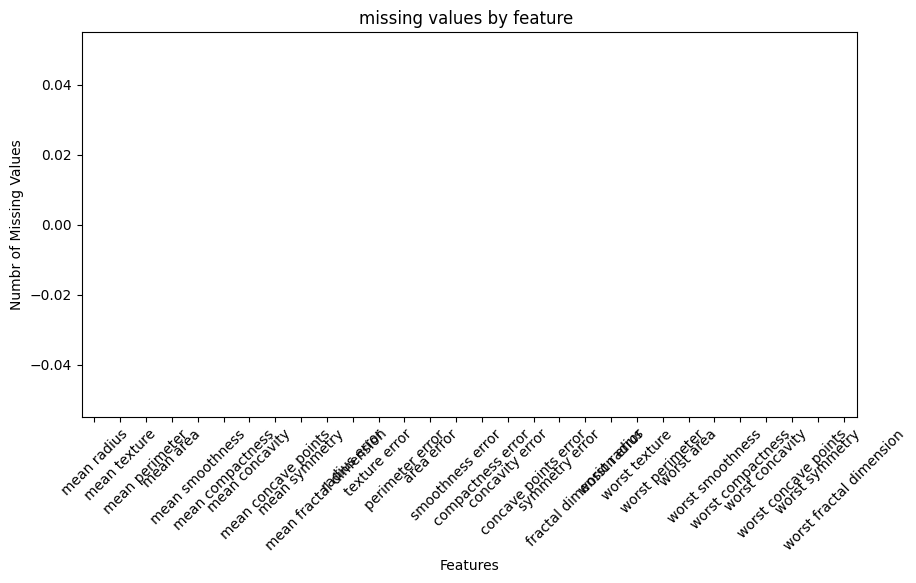

duplcicate rows 0


In [77]:
#plotting missing value bar-chart
plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind='bar')
plt.title("missing values by feature ")
plt.xlabel("Features")
plt.ylabel("Numbr of Missing Values")
plt.xticks(rotation=45)
plt.show()
print("duplcicate rows", df.duplicated().sum())

In [78]:
#min-max scaling
scaler = MinMaxScaler()
x= df.copy()
x[df.columns] = scaler.fit_transform(df[df.columns])

print(" Min-Max Scaling:")
display(x.head())

 Min-Max Scaling:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


In [79]:
y = raw_data.target
print("target variable y head:", y[:5])
print("target variable y shape:", y.shape)
print("target variable x head:",x[:5])
print("target variable c shape:",y.shape)

target variable y head: [0 0 0 0 0]
target variable y shape: (569,)
target variable x head:    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     0.521037      0.022658        0.545989   0.363733         0.593753   
1     0.643144      0.272574        0.615783   0.501591         0.289880   
2     0.601496      0.390260        0.595743   0.449417         0.514309   
3     0.210090      0.360839        0.233501   0.102906         0.811321   
4     0.629893      0.156578        0.630986   0.489290         0.430351   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          0.792037        0.703140             0.731113       0.686364   
1          0.181768        0.203608             0.348757       0.379798   
2          0.431017        0.462512             0.635686       0.509596   
3          0.811361        0.565604             0.522863       0.776263   
4          0.347893        0.463918             0.518390       0.378283   



In [80]:
# split the data into training and testing sets(70:30)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

print("shape of X_train:", X_train.shape)
print("shape of X_test:", X_test.shape)
print("shape of y_train:", y_train.shape)
print("shape of y_test:", y_test.shape)

shape of X_train: (398, 30)
shape of X_test: (171, 30)
shape of y_train: (398,)
shape of y_test: (171,)


###  Evaluating Models on Testing Data (30%)




#logistic regression model




In [81]:
#Training the logistic regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test,y_pred_log_reg ))
print("Precision Score:", precision_score(y_test, y_pred_log_reg, average='weighted'))
print("Recall Score:", recall_score(y_test, y_pred_log_reg, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log_reg, average='weighted'))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))

Accuracy Score: 0.9649122807017544
Precision Score: 0.9655600866573213
Recall Score: 0.9649122807017544
F1 Score: 0.9646560514550161

Confusion Matrix:
 [[ 58   5]
 [  1 107]]


# Decision Tree Classifier

In [82]:
#Training Decision Tree Classifier
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dec_tree = dec_tree_model.predict(X_test)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test,y_pred_dec_tree ))
print("Precision Score:", precision_score(y_test, y_pred_dec_tree, average='weighted'))
print("Recall Score:", recall_score(y_test, y_pred_dec_tree, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_dec_tree, average='weighted'))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dec_tree))

Accuracy Score: 0.9415204678362573
Precision Score: 0.9432896247507402
Recall Score: 0.9415204678362573
F1 Score: 0.9418684592468108

Confusion Matrix:
 [[ 60   3]
 [  7 101]]


# Confusion Matrix Comparison for Logistic Regression vs Decision Tree (Testing data)

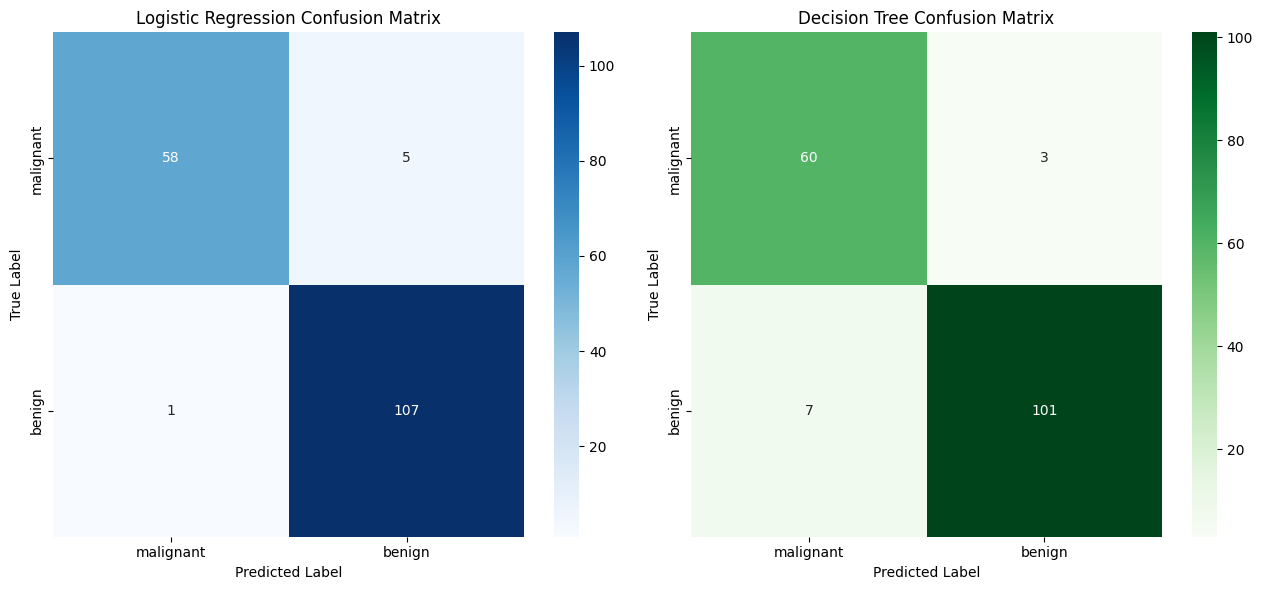

In [83]:
# Create a figure with two subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Plot Confusion Matrix for Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=raw_data.target_names, yticklabels=raw_data.target_names)
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Confusion Matrix for Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dec_tree), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=raw_data.target_names, yticklabels=raw_data.target_names)
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Evaluating Models on Training Data (70%)

#logistic regression model

In [84]:
# Make predictions on the training set for Logistic Regression
y_pred_log_reg_train = log_reg_model.predict(X_train)

# Evaluate Logistic Regression on training data
print("\nLogistic Regression Model Performance on Training Data:")
print("Accuracy Score:", accuracy_score(y_train, y_pred_log_reg_train))
print("Precision Score:", precision_score(y_train, y_pred_log_reg_train, average='weighted'))
print("Recall Score:", recall_score(y_train, y_pred_log_reg_train, average='weighted'))
print("F1 Score:", f1_score(y_train, y_pred_log_reg_train, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_log_reg_train))




Logistic Regression Model Performance on Training Data:
Accuracy Score: 0.9623115577889447
Precision Score: 0.9632929138445853
Recall Score: 0.9623115577889447
F1 Score: 0.9619965479114114

Confusion Matrix:
 [[136  13]
 [  2 247]]


# Decision Tree Classifier

In [85]:
# Make predictions on the training set for Decision Tree
y_pred_dec_tree_train = dec_tree_model.predict(X_train)

# Evaluate Decision Tree on training data
print("\nDecision Tree Classifier Model Performance on Training Data:")
print("Accuracy Score:", accuracy_score(y_train, y_pred_dec_tree_train))
print("Precision Score:", precision_score(y_train, y_pred_dec_tree_train, average='weighted'))
print("Recall Score:", recall_score(y_train, y_pred_dec_tree_train, average='weighted'))
print("F1 Score:", f1_score(y_train, y_pred_dec_tree_train, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_dec_tree_train))


Decision Tree Classifier Model Performance on Training Data:
Accuracy Score: 1.0
Precision Score: 1.0
Recall Score: 1.0
F1 Score: 1.0

Confusion Matrix:
 [[149   0]
 [  0 249]]


# Confusion Matrix Comparison for Logistic Regression vs Decision Tree (Training data)

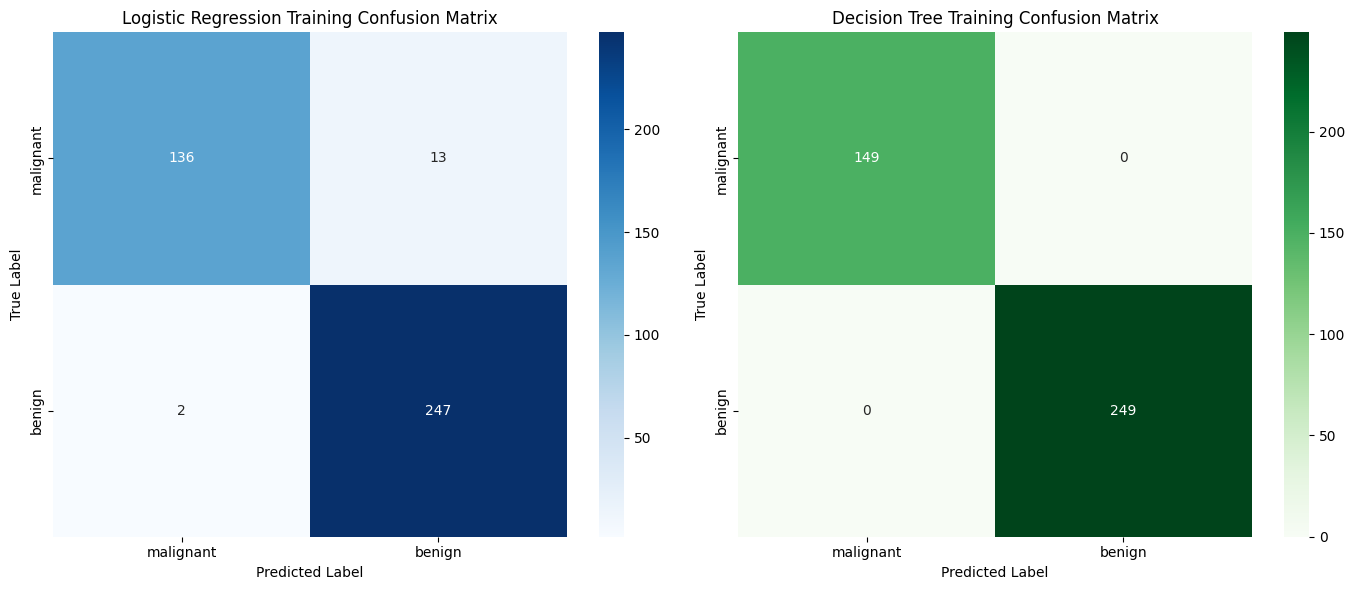

In [86]:
# Create a figure with two subplots for comparison of training confusion matrices
fig_train, axes_train = plt.subplots(1, 2, figsize=(14, 6))

# Plot Confusion Matrix for Logistic Regression on Training Data
sns.heatmap(confusion_matrix(y_train, y_pred_log_reg_train), annot=True, fmt='d', cmap='Blues', ax=axes_train[0],
            xticklabels=raw_data.target_names, yticklabels=raw_data.target_names)
axes_train[0].set_title('Logistic Regression Training Confusion Matrix')
axes_train[0].set_xlabel('Predicted Label')
axes_train[0].set_ylabel('True Label')

# Plot Confusion Matrix for Decision Tree on Training Data
sns.heatmap(confusion_matrix(y_train, y_pred_dec_tree_train), annot=True, fmt='d', cmap='Greens', ax=axes_train[1],
            xticklabels=raw_data.target_names, yticklabels=raw_data.target_names)
axes_train[1].set_title('Decision Tree Training Confusion Matrix')
axes_train[1].set_xlabel('Predicted Label')
axes_train[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Model Evaluation Summary

**MODEL EVALUATION ON TRAINING DATA (70%)**
*   Logistic Regression: 96.23% Accuracy
*   Decision Tree: 100.00% Accuracy

**MODEL EVALUATION ON TESTING DATA (30%)**
*   Logistic Regression: 96.49% Accuracy
*   Decision Tree: 94.15% Accuracy

**FINAL CONCLUSION**
*   Logistic Regression: Better Generalization
*   Decision Tree: Overfitting Observed

**Explanation:**
Logistic Regression performed more consistently on both the training and testing data. The Decision Tree achieved a perfect 100% accuracy on the training data but showed a drop to 94.15% accuracy on the testing data, which is a clear indication of overfitting.